# Imports and Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

df = pd.read_csv(path+'/creditcard.csv')


Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [2]:
print("Rows:",df.shape[0]," Columns:", df.shape[1])
print(df.head())

Rows: 284807  Columns: 31
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

      

In [3]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


From the count of time we can say there's about 284707 transection during 2 days in a row

# EDA



In [4]:
# Check if there's missing data
df.isna().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


No missing data

## Check Data Unbalance

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Percentage Distribution:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


/tmp/ipykernel_8603/2104324268.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


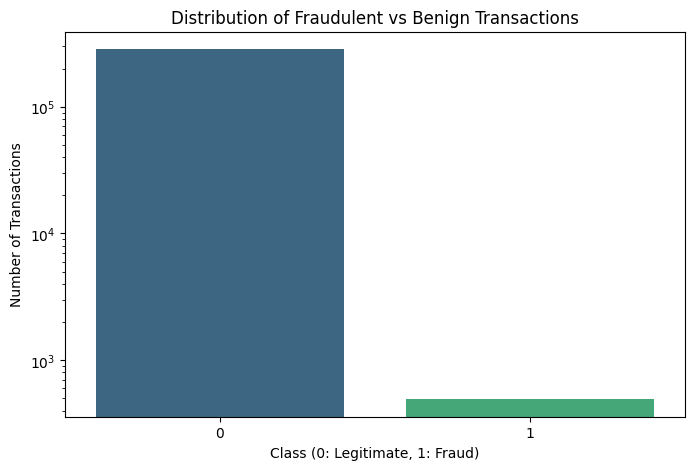

In [5]:
# Print raw counts and normalized percentages
print("Class Distribution:")
print(df['Class'].value_counts())
print("\nPercentage Distribution:")
print(df['Class'].value_counts(normalize=True) * 100)

# Visual Check
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Distribution of Fraudulent vs Benign Transactions')
plt.xlabel('Class (0: Legitimate, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.yscale('log') # Use log scale if fraud is extremely rare (e.g., < 0.1%)
plt.show()

492 (0.172%) of tansactions are fraud so the data is very unbalanced

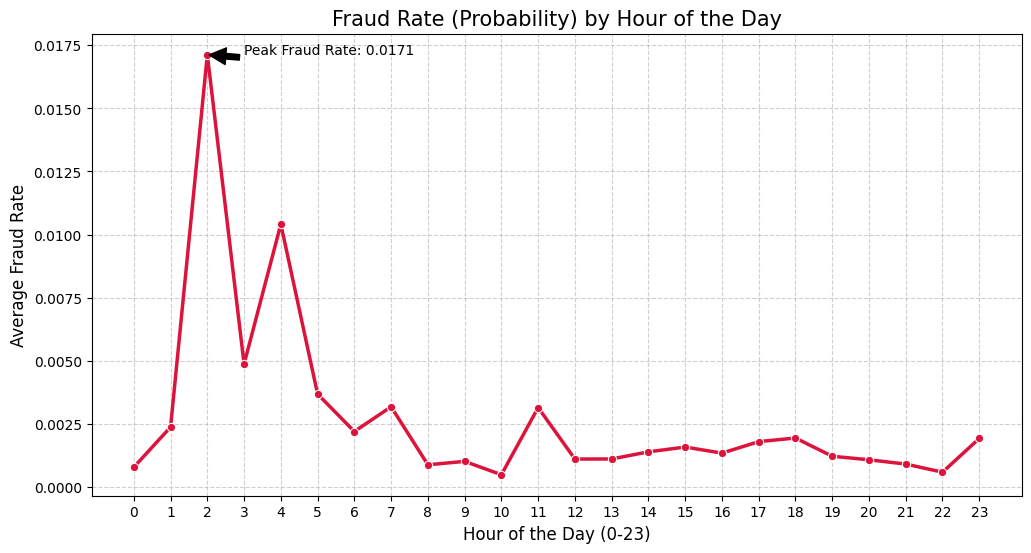

In [6]:

# Exract time
df['Hour'] = (df['Time'] // 3600) % 24

# Calculate the average fraud rate (mean of Class) for each hour
# Since Class is 0 or 1, the mean is exactly the probability of fraud.
fraud_rate = df.groupby('Hour')['Class'].mean()

# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(x=fraud_rate.index, y=fraud_rate.values, marker='o', color='crimson', linewidth=2.5)

plt.title('Fraud Rate (Probability) by Hour of the Day', fontsize=15)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Average Fraud Rate', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)

# Highlight high-risk hours
max_hour = fraud_rate.idxmax()
plt.annotate(f'Peak Fraud Rate: {fraud_rate.max():.4f}',
             xy=(max_hour, fraud_rate.max()),
             xytext=(max_hour+1, fraud_rate.max()),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

Most fraud operations happen in the quiet hours (after 2 am to 5 am)

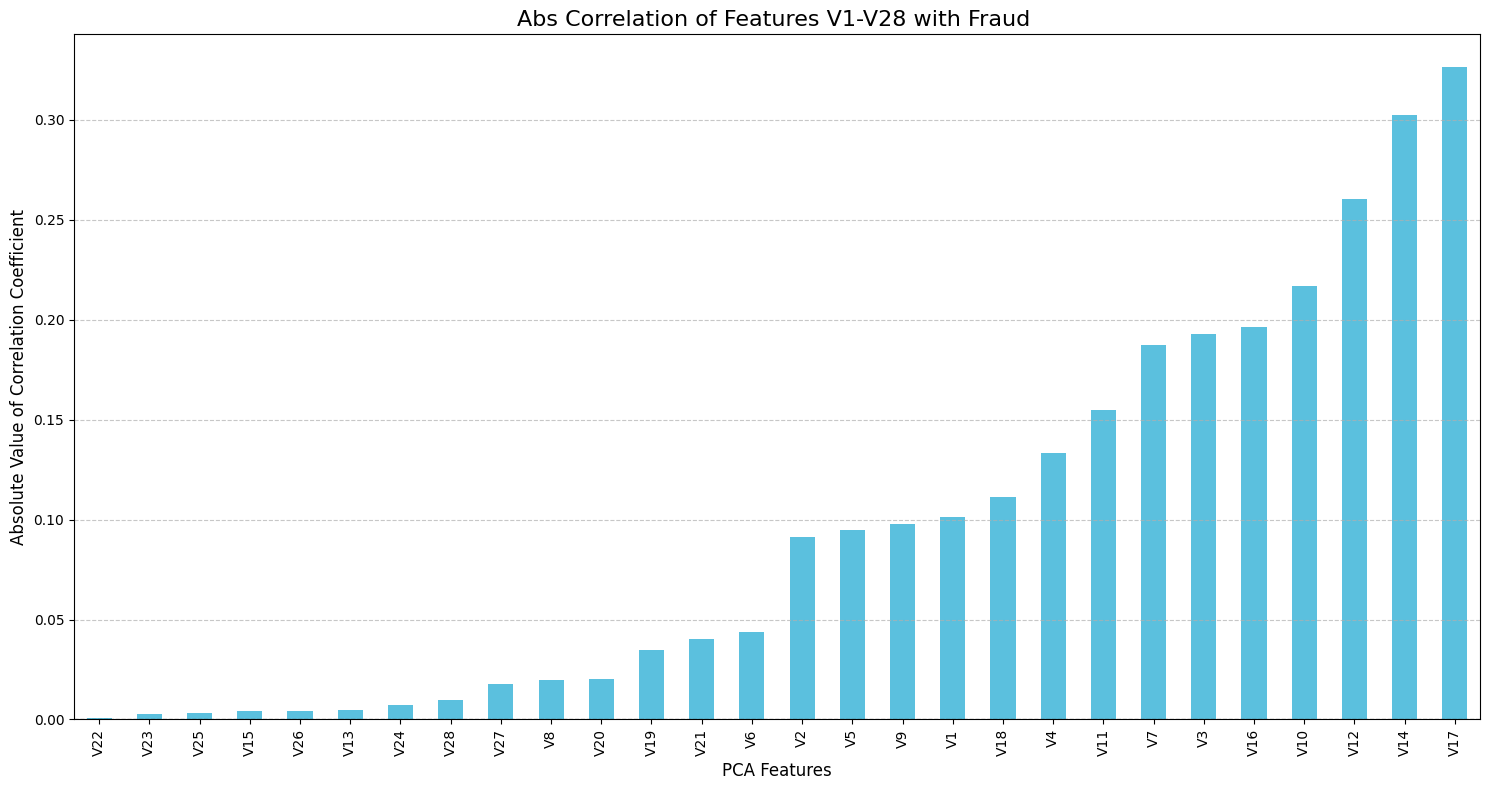

In [7]:

# Calculate correlation of all V features with Class
# We filter columns that start with 'V' and the 'Class' column itself
v_features = [f'V{i}' for i in range(1, 29)]
correlations_abs = df[v_features + ['Class']].corr()['Class'].drop('Class').abs().sort_values()
correlations = df[v_features + ['Class']].corr()['Class'].drop('Class').sort_values()

# Plotting the results
plt.figure(figsize=(15, 8))
colors = ['#5bc0de']
correlations_abs.plot(kind='bar', color=colors)

plt.title('Abs Correlation of Features V1-V28 with Fraud ', fontsize=16)
plt.ylabel('Absolute Value of Correlation Coefficient', fontsize=12)
plt.xlabel('PCA Features', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

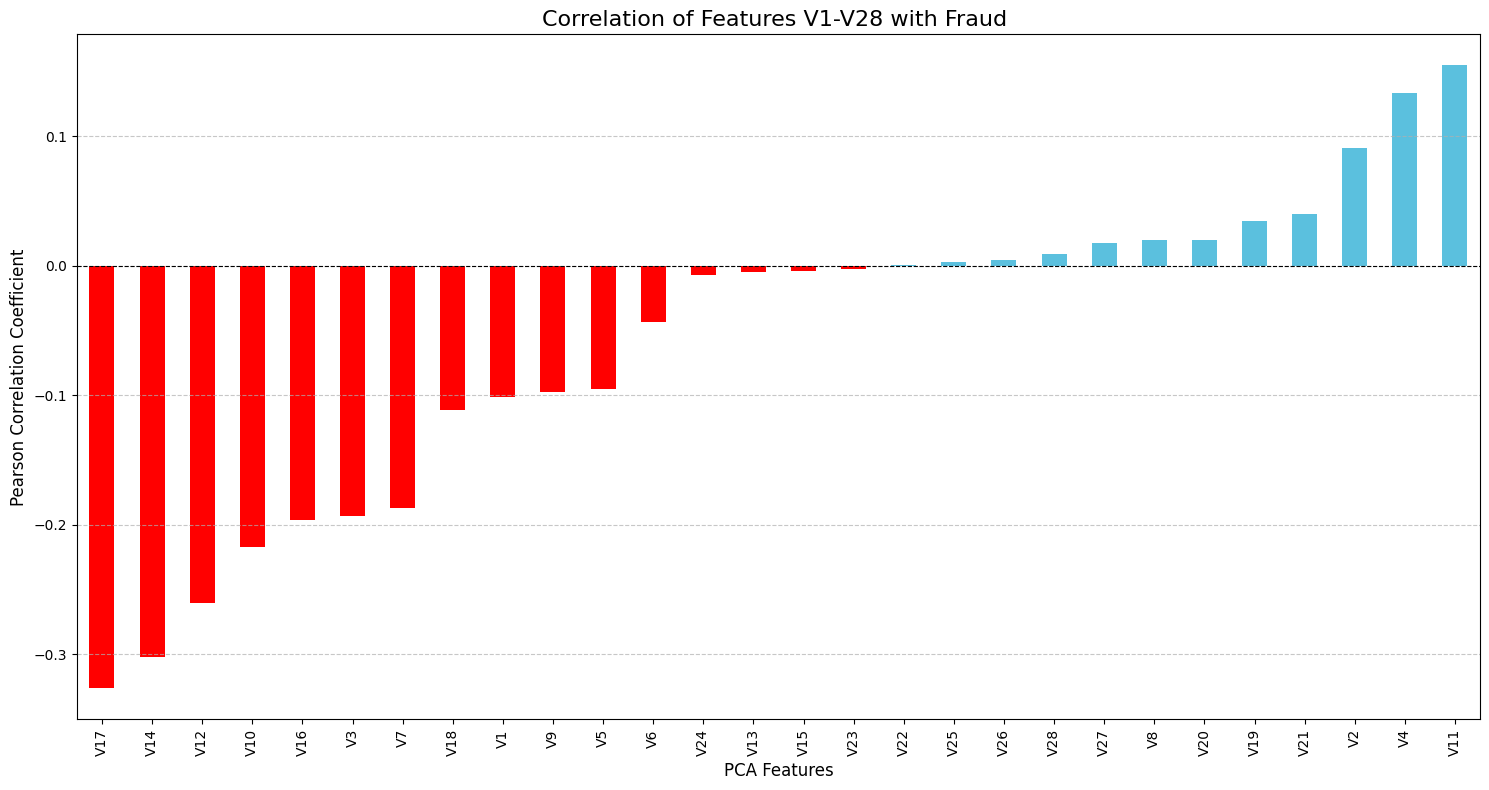

In [8]:
plt.figure(figsize=(15, 8))
colors = ['red' if (x<0) else '#5bc0de' for x in correlations]
correlations.plot(kind='bar', color=colors)

plt.title('Correlation of Features V1-V28 with Fraud ', fontsize=16)
plt.ylabel('Pearson Correlation Coefficient', fontsize=12)
plt.xlabel('PCA Features', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

1. Strong Negative Correlation: Features like V17, V14, V12, and V10 show the strongest negative correlations. This means that as these specific values decrease, the probability of the transaction being fraudulent increases.Strong


2. Positive Correlation: Features like V2, V4, and V11  are positive correlations. Higher values in these dimensions are associated with a higher likelihood of fraud.

3. Near-Zero Correlation: Several V features have coefficients close to 0. These features contribute little linearly to the detection of fraud and may be candidates for removal to simplify the model, though they might still contain non-linear information useful for tree-based models.

In [9]:
df['Hour'] = df['Time'].apply(lambda x: np.floor(x / 3600))
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0


In [10]:
tmp = df.groupby(['Hour', 'Class'])['Amount'].aggregate(['min', 'max', 'count', 'sum', 'mean', 'median', 'var']).reset_index()
df_group = pd.DataFrame(tmp)
df_group.columns = ['Hour', 'Class', 'Min', 'Max', 'Transactions', 'Sum', 'Mean', 'Median', 'Var']
df_group.head()

,Hour,Class,Min,Max,Transactions,Sum,Mean,Median,Var
0,0.0,0,0.0,7712.43,3961,256572.87,64.774772,12.990,45615.821201
1,0.0,1,0.0,529.00,2,529.00,264.500000,264.500,139920.500000
2,1.0,0,0.0,1769.69,2215,145806.76,65.826980,22.820,20053.615770
3,1.0,1,59.0,239.93,2,298.93,149.465000,149.465,16367.832450
4,2.0,0,0.0,4002.88,1555,106989.39,68.803466,17.900,45355.430437


In [11]:
df['hour_sin'] = np.sin(2 * np.pi * df['Hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour']/24)
df = df.drop(['Hour','Time'],axis=1)

In [12]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,Amount,Class,hour_sin,hour_cos
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0,1.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0,1.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0,1.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0,1.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0,1.0


In [13]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Define Features and Target
X = df.drop(['Class'], axis=1)
y = df['Class']

# Calculate the split point (e.g., 80%)
split_idx = int(len(df) * 0.8)

# Split based on time
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df.drop(['Class'], axis=1)
y_train = train_df['Class']
X_test = test_df.drop(['Class'], axis=1)
y_test = test_df['Class']

# Scaling numerical features which are only amount
scaler = StandardScaler()
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])

# Apply SMOTE to the Training Data ONLY
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original Train Class Distribution: {y_train.value_counts().to_dict()}")
print(f"Resampled Train Class Distribution: {y_train_res.value_counts().to_dict()}")

Original Train Class Distribution: {0: 227428, 1: 417}
Resampled Train Class Distribution: {0: 227428, 1: 227428}


Using time-split is necessary because we will only be meeting future  data after the model is in use and if we can't predict the future transactions then this model is useless

If the model fails on the last 20% of time, it means that the features aren't robust enough to handle shifting fraudster behavior.

# Modeling
1. LR

2. XGBoost

3. Isolation forest

In [14]:
from sklearn.metrics import precision_recall_curve, auc

def PR_AUC(y_test,y_pred):
  precision, recall, thresholds = precision_recall_curve(y_test, y_pred)
  return(auc(recall, precision))


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve

# We use 'liblinear' for small/medium datasets or 'saga' for larger one
lr_baseline = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

# Train on the training data
lr_baseline.fit(X_train_res, y_train_res)

# Predict on the "Future" Test Set (the last 20%)
y_pred = lr_baseline.predict(X_test)
y_probs = lr_baseline.predict_proba(X_test)[:, 1]

# Evaluate with Fraud-Specific Metrics
print("Baseline Logistic Regression Report (Temporal Test Set):")
print(classification_report(y_test, y_pred))
print(f"Average Precision (AUPRC): {average_precision_score(y_test, y_probs):.4f}")
print(f"PR_AUC = {PR_AUC(y_test,y_probs)}")

Baseline Logistic Regression Report (Temporal Test Set):
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56887
           1       0.03      0.92      0.06        75

    accuracy                           0.96     56962
   macro avg       0.51      0.94      0.52     56962
weighted avg       1.00      0.96      0.98     56962

Average Precision (AUPRC): 0.7729
PR_AUC = 0.7785662446407218


In [16]:
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coef': lr_baseline.coef_[0]})
print(coef_df.sort_values(by='Coef', ascending=False))

     Feature      Coef
28    Amount  2.731116
1         V2  0.955715
27       V28  0.910490
4         V5  0.886200
3         V4  0.839857
22       V23  0.759758
0         V1  0.753793
10       V11  0.613009
21       V22  0.611239
2         V3  0.534372
18       V19  0.323450
24       V25  0.194546
14       V15 -0.014590
20       V21 -0.105512
25       V26 -0.147913
17       V18 -0.245733
8         V9 -0.252602
26       V27 -0.294561
30  hour_cos -0.299727
7         V8 -0.305843
12       V13 -0.331588
23       V24 -0.339813
5         V6 -0.698328
6         V7 -0.747989
16       V17 -0.776597
15       V16 -0.790518
9        V10 -0.902399
29  hour_sin -1.045100
19       V20 -1.220853
13       V14 -1.263569
11       V12 -1.323604


In [17]:
from xgboost import XGBClassifier

# Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train on the training data
xgb_model.fit(X_train_res, y_train_res)

# Predict on the Test Set
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_probs_xgb >= 0.5).astype(int)

print(f"XGBoost AUPRC: {average_precision_score(y_test, y_probs_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))
print(f"PR-AUC = {PR_AUC(y_test,y_probs_xgb)}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:41:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUPRC: 0.7751
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.49      0.77      0.60        75

    accuracy                           1.00     56962
   macro avg       0.75      0.89      0.80     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC = 0.7748880025544495


It's better than LR but still we can do better

In [18]:
from sklearn.ensemble import IsolationForest

# Initialize Isolation Forest
# contamination: the expected proportion of outliers (your fraud rate ~0.0017)
iso_forest = IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination=0.0017,
    random_state=42
)

# Fit on the ORIGINAL X_train (No SMOTE) because we need it try to find the outliers
iso_forest.fit(X_train)

# predict returns -1 (anomaly) and 1 (normal)
# Get raw scores (lower = more anomalous)
# The decision_function returns values where negative is anomalous
raw_scores = iso_forest.decision_function(X_test)

for p in [0.1, 0.2, 0.5, 1]:
    threshold = np.percentile(raw_scores, p)
    y_pred_custom = [1 if x <= threshold else 0 for x in raw_scores]
    # Evaluate
    print(f"Isolation Forest (Top {p}% Anomaly Threshold):")
    print(classification_report(y_test, y_pred_custom))
    pr_auc = PR_AUC(y_test, -raw_scores)
    print(f"pr_auc = {pr_auc}")

Isolation Forest (Top 0.1% Anomaly Threshold):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.00      0.00      0.00        75

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962

pr_auc = 0.04570228376088083
Isolation Forest (Top 0.2% Anomaly Threshold):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.06      0.09      0.07        75

    accuracy                           1.00     56962
   macro avg       0.53      0.55      0.54     56962
weighted avg       1.00      1.00      1.00     56962

pr_auc = 0.04570228376088083
Isolation Forest (Top 0.5% Anomaly Threshold):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.07      0.25     

In [19]:
import lightgbm as lgb

# Initialize LightGBM
lgbm_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=31,         # Main parameter to control complexity
    boosting_type='gbdt',
    random_state=42,
    importance_type='gain', # Use 'gain' to match your XGBoost/LogReg logic
    n_jobs=-1
)

# Train on SMOTE-resampled data
lgbm_model.fit(X_train_res, y_train_res)

# Predict on the "Future" Test Set (Last 20%)
y_probs_lgbm = lgbm_model.predict_proba(X_test)[:, 1]
y_pred_lgbm = (y_probs_lgbm >= 0.5).astype(int)

# Evaluate
print(f"LightGBM AUPRC: {average_precision_score(y_test, y_probs_lgbm):.4f}")
print(classification_report(y_test, y_pred_lgbm))
print(f'PR_AUC = {PR_AUC(y_test,y_probs_lgbm)}')

[LightGBM] [Info] Number of positive: 227428, number of negative: 227428
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.120428 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7905
[LightGBM] [Info] Number of data points in the train set: 454856, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM AUPRC: 0.7762
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.29      0.81      0.43        75

    accuracy                           1.00     56962
   macro avg       0.64      0.91      0.71     56962
weighted avg       1.00      1.00      1.00     56962

PR_AUC = 0.7756357933032989


Let's try to use the isolation forest as a Feature generator

In [20]:
X_train['iso_score'] = iso_forest.decision_function(X_train)
X_test['iso_score'] = iso_forest.decision_function(X_test)

In [21]:
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


In [22]:
# Train on the training data
xgb_model.fit(X_train_res, y_train_res)

# Predict on the Test Set
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_probs_xgb >= 0.5).astype(int)

print(f"XGBoost AUPRC: {average_precision_score(y_test, y_probs_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))
print(f"PR-AUC = {PR_AUC(y_test,y_probs_xgb)}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:41:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUPRC: 0.7721
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.37      0.77      0.50        75

    accuracy                           1.00     56962
   macro avg       0.69      0.89      0.75     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC = 0.7719532690804207


It got worse let's try XGBoost but without SMOTE

In [23]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight = 600
)
xgb_model.fit(X_train,y_train)

# Predict on the Test Set
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_probs_xgb >= 0.5).astype(int)

print(f"XGBoost AUPRC: {average_precision_score(y_test, y_probs_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))
print(f"PR-AUC = {PR_AUC(y_test,y_probs_xgb)}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:41:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUPRC: 0.7731
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.76      0.75      0.75        75

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.88     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC = 0.7727950999192013


In [25]:
from sklearn.metrics import roc_auc_score
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight = 200
)
xgb_model.fit(X_train,y_train)

# Predict on the Test Set
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_probs_xgb >= 0.5).astype(int)

print(f"XGBoost AUPRC: {average_precision_score(y_test, y_probs_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))
print(f"PR-AUC = {PR_AUC(y_test,y_probs_xgb)}")
print(f"AUC = {roc_auc_score(y_test,y_probs_xgb)}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:41:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUPRC: 0.8029
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.85      0.76      0.80        75

    accuracy                           1.00     56962
   macro avg       0.93      0.88      0.90     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC = 0.8026016249726835
AUC = 0.9846420681936705


This is the best model let's check if it's going to be correct in a time series split

In [26]:
from sklearn.model_selection import TimeSeriesSplit

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
f1_results = []
threshold_results = []
best_thresholds = []

for train_index, test_index in tscv.split(X):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Define and Fit Model
    model = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=42, eval_metric='logloss', scale_pos_weight=200
    )
    model.fit(X_train_fold, y_train_fold)

    # Predict Probabilities
    y_probs = model.predict_proba(X_test_fold)[:, 1]

    # Optimize Threshold for THIS specific time window
    precision, recall, thresholds = precision_recall_curve(y_test_fold, y_probs)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

    best_idx = np.argmax(f1_scores)
    f1_results.append(f1_scores[best_idx])
    # Handle threshold index edge case
    best_thresholds.append(thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1])

print(f"--- TimeSeriesSplit Results (5 Folds) ---")
print(f"Mean F1 Score: {np.mean(f1_results):.4f}")
print(f"Standard Deviation: {np.std(f1_results):.4f}")
print(f"Mean Optimal Threshold: {np.mean(best_thresholds):.4f}")

--- TimeSeriesSplit Results (5 Folds) ---
Mean F1 Score: 0.8244
Standard Deviation: 0.0063
Mean Optimal Threshold: 0.7573


A standard deviation of less than 1% means that the model is very stable and consistent which means that if the recall is acceptable we can actually use this model by training it on 100% of the data and hard lock the threshold to be 0.7573 (0.76) and during production i will check the precision if it starts to drop than 0.70 meaning that theres' a new blindspot and we will need to retrain

# Threshold Tuning

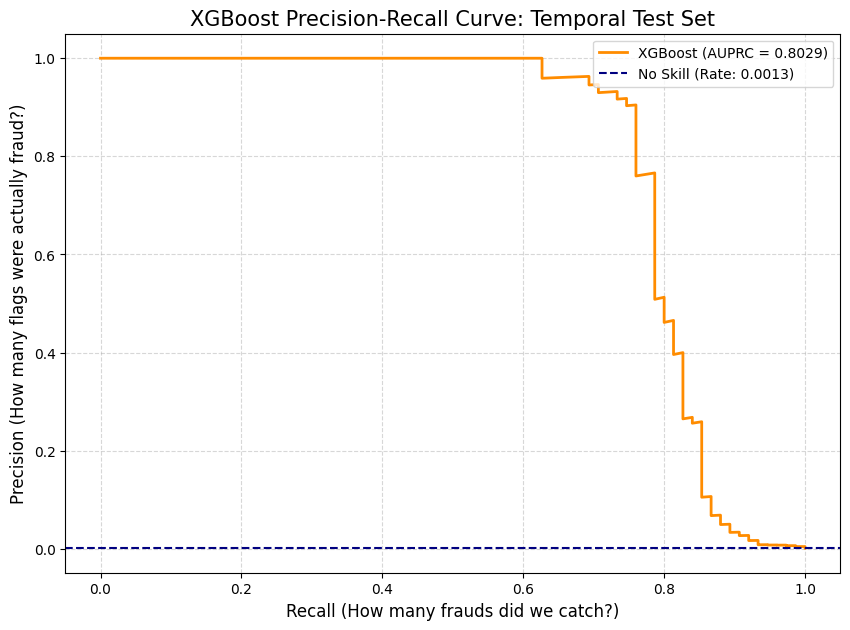

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

# Get the predicted probabilities for the positive class (Fraud)
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# Calculate Precision and Recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
auprc = average_precision_score(y_test, y_probs)

# Create the Plot
plt.figure(figsize=(10, 7))
plt.plot(recall, precision, color='darkorange', lw=2, label=f'XGBoost (AUPRC = {auprc:.4f})')

# Plot the "No Skill" Baseline
no_skill = len(y_test[y_test == 1]) / len(y_test)
plt.axhline(y=no_skill, color='navy', linestyle='--', label=f'No Skill (Rate: {no_skill:.4f})')

plt.title('XGBoost Precision-Recall Curve: Temporal Test Set', fontsize=15)
plt.xlabel('Recall (How many frauds did we catch?)', fontsize=12)
plt.ylabel('Precision (How many flags were actually fraud?)', fontsize=12)
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [28]:
# Add a tiny epsilon to avoid division by zero
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_f1_idx]

print(f"--- F1 Optimization ---")
print(f"Best Threshold for F1: {best_f1_threshold:.4f}")
print(f"Max F1-Score: {f1_scores[best_f1_idx]:.4f}")

# We find indices where recall is at least 0.90
# Then from those, we pick the one with the highest precision
recall_90_indices = np.where(recall >= 0.90)[0]
best_recall_90_idx = recall_90_indices[np.argmax(precision[recall_90_indices])]
threshold_90_recall = thresholds[best_recall_90_idx]

print(f"\n--- 90% Recall Constraint ---")
print(f"Threshold for 90% Recall: {threshold_90_recall:.4f}")
print(f"Precision at this Recall: {precision[best_recall_90_idx]:.4f}")

--- F1 Optimization ---
Best Threshold for F1: 0.6382
Max F1-Score: 0.8261

--- 90% Recall Constraint ---
Threshold for 90% Recall: 0.0054
Precision at this Recall: 0.0341


For the 90% recall it's so bad.
For every 1 actual fraud to catch, we are flagging approximately 40 legitimate customers.

To catch 68 out of the 75 frauds (90%), we would be sending over 2,800 false alarms to our investigation team or declining 2,800 valid transactions.

The threshold being at 0.006 meaning that the 15% difference are almost identical to legitimate transections which doesn't do well in a production so we will use the 0.800 max F1

Or we might use tiers approcah which instead of one thershold we go for three thersholds
- High Certainty (> 0.97): Auto-decline. (High Precision, Moderate Recall).

- Medium Certainty (0.50 - 0.97): Flag for manual review or trigger Multi-Factor Authentication (MFA).

- Low Certainty (< 0.50): Approved.


In [29]:
best_precision = precision[best_f1_idx]
best_recall = recall[best_f1_idx]

print(f"Final Model Stats (Threshold 0.8209):")
print(f"Precision: {best_precision:.4f}")
print(f"Recall: {best_recall:.4f}")
print(f"F1-Score: {f1_scores[best_f1_idx]:.4f}")


best_precision_90 = precision[best_recall_90_idx]
best_recall_90 = recall[best_recall_90_idx]

print(f"90% Recall Model (Threshold 0.0048):")
print(f"Precision: {best_precision_90:.4f}")
print(f"Recall: {best_recall_90:.4f}")
print(f"F1-Score: {f1_scores[best_recall_90_idx]:.4f}")



Final Model Stats (Threshold 0.8209):
Precision: 0.9048
Recall: 0.7600
F1-Score: 0.8261
90% Recall Model (Threshold 0.0048):
Precision: 0.0341
Recall: 0.9067
F1-Score: 0.0656


# 5 Interpretability
Shap

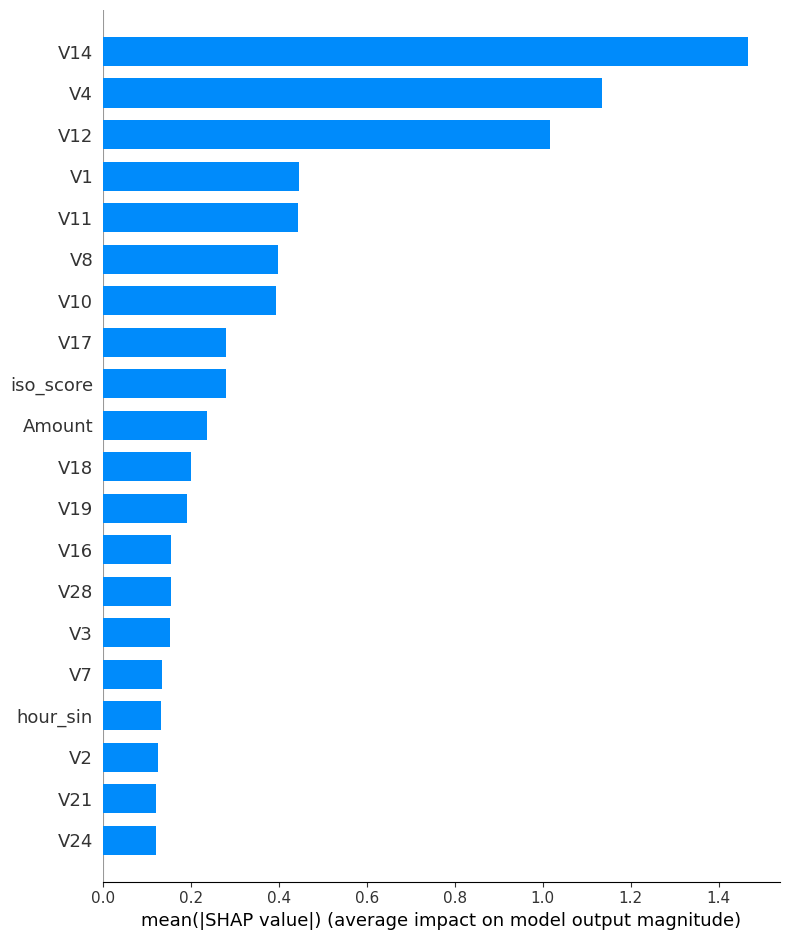

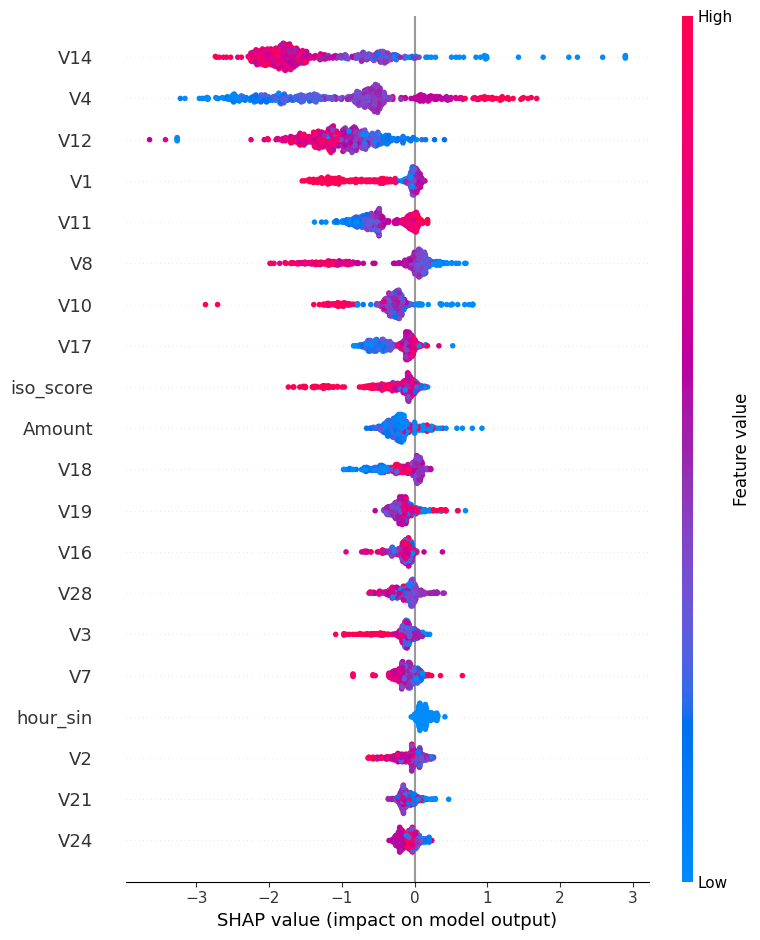

In [30]:
import shap

# Initialize the Explainer
explainer = shap.TreeExplainer(xgb_model)

# Select a sample of 500 rows from your test set

X_sample = X_test.iloc[:500]
shap_values = explainer.shap_values(X_sample)

# Summary Plot (Global Importance)
# This shows which features are the most powerful across all 500 samples
shap.summary_plot(shap_values, X_sample, plot_type="bar")

# Detailed Summary Plot (Beeswarm)
plt.figure()
shap.summary_plot(shap_values, X_sample)



So the top 3 features are V14 , V4 and V12
where low values in V14 driving the model into thinking that it's a fraud same with V12 and vice versa in V4

- iso_score Impact: Since iso_score usually represents how "isolated" a point is, look at the color distribution. If low scores (more anomalous) are associated with positive SHAP values, it means XGBoost is successfully using the anomaly detection signal to confirm its own suspicions.

Showing Waterfall plot for True Positive at index: 1867
Model Probability: 0.9997


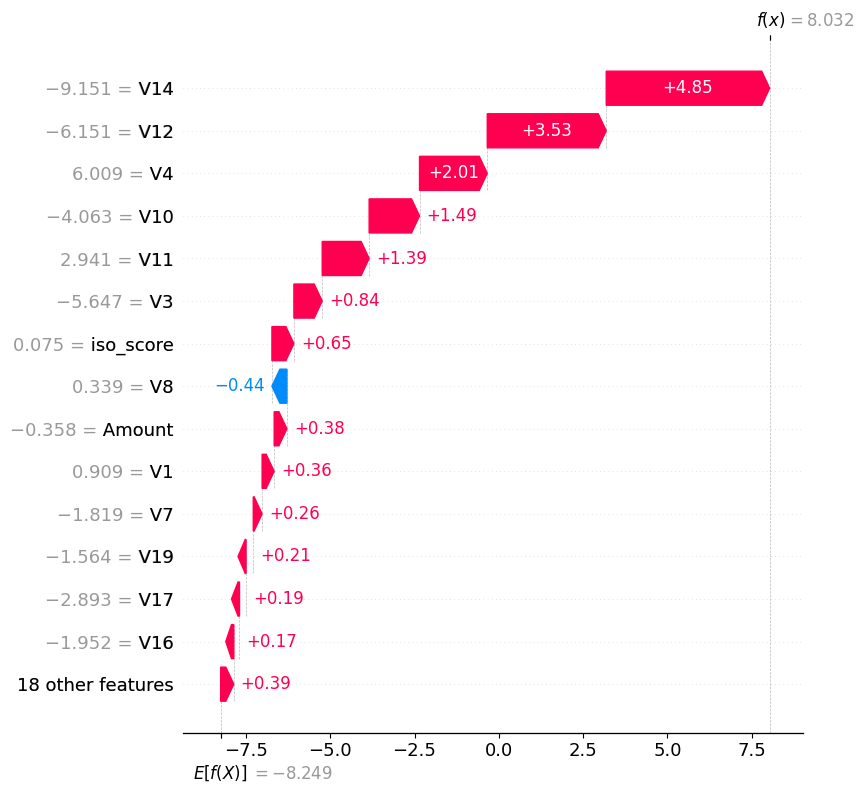

In [33]:
# Get probabilities for the test set
test_probs = xgb_model.predict_proba(X_test)[:, 1]

# Define your optimal threshold
threshold = 0.7573

# Find indices of True Positives (Actual == 1 AND Predicted == 1)
true_positive_indices = np.where((y_test == 1) & (test_probs >= threshold))[0]

if len(true_positive_indices) > 0:
    # Pick the first successfully detected fraud
    tp_idx = true_positive_indices[0]
    print(f"Showing Waterfall plot for True Positive at index: {tp_idx}")
    print(f"Model Probability: {test_probs[tp_idx]:.4f}")
else:
    print("No True Positives found in this sample.")

# Initialize the explainer and calculate SHAP values for this specific row
explainer = shap.Explainer(xgb_model, X_train)
shap_values_single = explainer(X_test.iloc[tp_idx : tp_idx + 1])

# Plotting
plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_values_single[0], max_display=15)

We can see here since the values of V14 and V12 are low and V4 is high it pushed the model into thinking that it's fraud

Also iso_score supposed to show anamolus values so it also pushed the model

# Questions
Why is Precision-Recall AUC more informative than ROC-AUC for this dataset specifically?
The Flaw of ROC-AUC: If a model simply predicts "Legitimate" for every single transaction, it gets a high ROC-AUC because it correctly identified 99.8% of the data.

- The Reality: For fraud, we don't care how good the model is at finding "normal" that's easy. We care about the Precision (how many alerts are real) and Recall (how many frauds we caught).

- So PR-AUC actually ignores the easy million non fraud cases and focus on the 492 frauds and the false alarms


SMOTE generates synthetic samples by interpolating between real minority class examples. What is one scenario where SMOTE would actively hurt your model's real-world performance?

- smote works by drawing a line between 2 minority class exmaples and placing a synthetic point on it, now imagine if between those 2 points there tons of majority class so this point is simply a failure as it will make the model see a blurry decision boundary because of this, this is probably happened when using scale_pos_weight instead of SMOTE

- The more precise framing: SMOTE doesn't check whether the interpolated region is actually safe


Your model achieves 95% Recall on fraud. A business stakeholder says "that means we're catching 95% of fraud, we're done." What are the two things they are ignoring?

- They are simply ignoring the precision as in my example having 95% fraud detection will probably lead to something worse than the 0.0241 precision the model will then need way more human cost to invisitgate (probably will invisitigae everybody)

- Also 95% Recall at the current threshold is meaningless without knowing the operating cost of the 5% miss rate — what is the dollar value of the fraud that slips through? If those 5% are all high-value transactions ($50,000+), catching 95% of low-value fraud while missing 5% of high-value fraud is a poor outcome. Recall ignores the severity distribution of what's being missed.

The V1–V28 features are PCA components from the original transaction data. You cannot interpret them directly. Does this limit the usefulness of SHAP values in this context, and how would you communicate your findings to a non-technical audience anyway?

- Even without knowing what these features are ,they are very reliable if V14 was the top today and tomorrow it's V5 then it means that the fraudsters changed their tactics

- we can say think of the V-features as digital fingerprints. We don't need to know the person's name to know that this specific fingerprint pattern is 200 times more likely to belong to a fraudster than a customer.

